# Train, Validate & Forecast Avatar 3 Opening Weekend

## Objective

Build and validate machine learning models to forecast Avatar 3's domestic opening weekend revenue using pre-processed theatrical release data with strict time-aware evaluation.

## Scope

**In scope:**
- Load pre-processed, encoded training data (~9,800 films)
- Data integrity verification (proving preprocessing quality)
- Train & evaluate exactly 3 models with temporal validation
- Generate Avatar 3 point forecast + uncertainty interval
- Export reproducible artifacts

**Out of scope:**
- Feature engineering or web scraping
- Schema modifications or column renaming
- Hyperparameter optimization loops

**Note:** ETL and preprocessing were completed in `01_box_office_dataset_builder.ipynb` (link: _____)

## Hard Guarantees

1. **Time-aware evaluation**: Train/validation split strictly by `release_year`; no future leakage
2. **Log-transformed target**: `log1p(opening_weekend)` for heavy-tailed revenue modeling
3. **Strict schema alignment**: Avatar 3 input must match training feature schema exactly
4. **Artifact export**: Model, features, metrics, and predictions saved for reproducibility

## Table of Contents

1. [Configuration & Paths](#config)
2. [Imports & Version Logging](#imports)
3. [Load Training Dataset](#load-data)
4. [Data Integrity & Schema Checks](#integrity)
5. [Feature Partitioning & Leakage Guardrails](#features)
6. [Target Definition & Log Transform](#target)
7. [Time-Based Split](#split)
8. [Baseline Model](#baseline)
9. [Candidate ML Models](#candidates)
10. [Time-Aware Evaluation Loop](#evaluation)
11. [Diagnostics & Robustness](#diagnostics)
12. [Model Selection & Freezing](#selection)
13. [Final Training on Full Data](#final-train)
14. [Load & Validate Avatar 3 Input](#avatar3-load)
15. [Avatar 3 Point Prediction](#avatar3-predict)
16. [Uncertainty Estimation](#uncertainty)
17. [Sanity Check vs Comparable Films](#sanity)
18. [Final Forecast Summary](#summary)
19. [Export Artifacts](#export)

<a id="config"></a>
## 1. Configuration & Paths

Central configuration cell containing all file paths, column definitions, split parameters, and reproducibility settings. Modify these values to adapt the notebook to different environments or experiments.

In [39]:
# =============================================================================
# CONFIGURATION & PATHS
# =============================================================================
from pathlib import Path

# --- File Paths ---
# Google Drive direct download URLs (converted from sharing links)
TRAIN_PATH = "https://drive.google.com/uc?id=1bSDSeioveCWikikIfYMdcC9Ei_5Tkl_Q"
AVATAR3_PATH = "https://drive.google.com/uc?id=1WAxnBr2-jmVms8MrLC3gyIIM1ies2IDU"
ARTIFACT_DIR = Path("artifacts/avatar3_forecast")

# --- Column Definitions ---
TARGET = "opening_weekend"
TIME_COL = "release_year"
ID_COLS = ["title"]

# --- Time-Based Split Configuration ---
# All films with release_year < SPLIT_YEAR go to training
# All films with release_year >= SPLIT_YEAR go to validation
SPLIT_YEAR = 2022

# --- Reproducibility ---
RANDOM_STATE = 42

# --- Evaluation Settings ---
METRIC_REPORTING = ["rmse_usd", "mape"]

# --- Uncertainty Estimation ---
# Using validation error percentiles for prediction intervals
INTERVAL_COVERAGE = 0.80  # 80% prediction interval
LOWER_PERCENTILE = 10     # (100 - 80) / 2
UPPER_PERCENTILE = 90     # 100 - lower

# --- Create artifact directories ---
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
print(f"✓ Artifact directory ready: {ARTIFACT_DIR.resolve()}")

✓ Artifact directory ready: C:\Users\khale\Downloads\artifacts\avatar3_forecast


<a id="imports"></a>
## 2. Imports & Version Logging

Load all required libraries and log versions for reproducibility. Setting the random seed ensures consistent results across runs.

In [40]:
# =============================================================================
# IMPORTS & VERSION LOGGING
# =============================================================================
import json
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.linear_model import Ridge
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import sklearn

import xgboost as xgb

from IPython.display import display, Markdown, HTML

# Suppress non-critical warnings for cleaner output
warnings.filterwarnings('ignore', category=FutureWarning)

# Set random seed for reproducibility
np.random.seed(RANDOM_STATE)

# Log library versions
print("=" * 50)
print("LIBRARY VERSIONS")
print("=" * 50)
print(f"pandas:   {pd.__version__}")
print(f"sklearn:  {sklearn.__version__}")
print(f"xgboost:  {xgb.__version__}")
print(f"numpy:    {np.__version__}")
print("=" * 50)

LIBRARY VERSIONS
pandas:   2.2.2
sklearn:  1.4.2
xgboost:  3.1.2
numpy:    1.26.4


<a id="load-data"></a>
## 3. Load Training Dataset

Load the pre-processed training dataset and perform initial inspection. The data has already been encoded and cleaned in the preprocessing pipeline.

In [41]:
# =============================================================================
# LOAD TRAINING DATASET
# =============================================================================
df = pd.read_csv(TRAIN_PATH)

print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nColumn count by dtype:")
print(df.dtypes.value_counts())

print(f"\n--- First 3 rows (preview) ---")
df.head(3)

Dataset shape: 9,847 rows × 45 columns

Column count by dtype:
int64      37
float64     7
object      1
Name: count, dtype: int64

--- First 3 rows (preview) ---


,title,release_year,is_summer,is_holiday,is_q1_dump_window,is_spring_dead_zone,is_awards_season,log_budget,has_budget,runtime_minutes,...,genre_western,is_major_studio,is_english,is_collection,collection_past_open_avg,director_has_prior,director_prior_count,lead_actor_has_prior,lead_actor_prior_count,opening_weekend
0,The Simpsons Movie,2007,1,0,0,0,0,18.132999,1.0,87.0,...,0,0,1,1,0.00,1,2.0,1,61.0,74036787.0
1,Indiana Jones and the Kingdom of the Crystal S...,2008,1,0,0,0,0,19.035866,1.0,122.0,...,0,1,1,1,20999318.00,1,32.0,1,84.0,100137835.0
2,Harry Potter and the Half-Blood Prince,2009,1,0,0,0,0,19.336971,1.0,153.0,...,0,1,1,1,93756359.25,1,8.0,1,12.0,77835727.0


<a id="integrity"></a>
## 4. Data Integrity & Schema Checks

These checks verify that the dataset is properly preprocessed and consistent:
- **Required columns exist**: Ensures core columns (`target`, `time`, `identifier`) are present
- **Temporal validity**: Release years fall within plausible range (1900–2030)
- **Target sanity**: Revenue values are non-negative with reasonable distribution
- **Dtype profile**: Confirms majority of features are numeric (evidence of encoding)
- **Missingness audit**: Identifies columns with excessive missing data
- **Constant features**: Detects zero-variance columns that provide no predictive signal
- **Duplicate handling**: Removes exact duplicate rows (safe operation)

A threshold of 70% missing is used — columns exceeding this provide minimal signal and likely indicate structural issues.

In [42]:
# =============================================================================
# DATA INTEGRITY & SCHEMA CHECKS
# =============================================================================

print("=" * 60)
print("DATA INTEGRITY CHECKS")
print("=" * 60)

# -----------------------------------------------------------------------------
# 1. Required columns exist
# -----------------------------------------------------------------------------
required_cols = [TARGET, TIME_COL] + ID_COLS
missing_required = [c for c in required_cols if c not in df.columns]
assert len(missing_required) == 0, f"Missing required columns: {missing_required}"
print(f"✓ Required columns present: {required_cols}")

# -----------------------------------------------------------------------------
# 2. Release year type sanity and plausible range
# -----------------------------------------------------------------------------
# Convert to numeric if needed
if df[TIME_COL].dtype == 'object':
    df[TIME_COL] = pd.to_numeric(df[TIME_COL], errors='coerce')
    print(f"  → Converted {TIME_COL} to numeric")

year_min, year_max = df[TIME_COL].min(), df[TIME_COL].max()
assert 1900 <= year_min <= 2030, f"Year min {year_min} out of plausible range"
assert 1900 <= year_max <= 2030, f"Year max {year_max} out of plausible range"
print(f"✓ Release year range: {int(year_min)} – {int(year_max)}")

# -----------------------------------------------------------------------------
# 3. Target sanity checks
# -----------------------------------------------------------------------------
target_missing_pct = df[TARGET].isna().mean() * 100
target_negative = (df[TARGET] < 0).sum()

print(f"\n--- Target Column: {TARGET} ---")
print(f"  Missing rate: {target_missing_pct:.2f}%")
print(f"  Negative values: {target_negative}")
assert target_negative == 0, "Target contains negative values!"

# Quantile distribution (evidence of numeric, sensible data)
quantiles = df[TARGET].quantile([0.01, 0.25, 0.50, 0.75, 0.99])
print(f"  Quantiles (USD):")
print(f"    p1:  ${quantiles[0.01]:>15,.0f}")
print(f"    p25: ${quantiles[0.25]:>15,.0f}")
print(f"    p50: ${quantiles[0.50]:>15,.0f}")
print(f"    p75: ${quantiles[0.75]:>15,.0f}")
print(f"    p99: ${quantiles[0.99]:>15,.0f}")

# -----------------------------------------------------------------------------
# 4. Dtype profile
# -----------------------------------------------------------------------------
print(f"\n--- Dtype Profile ---")
dtype_counts = df.dtypes.apply(lambda x: x.name).value_counts()
for dtype, count in dtype_counts.items():
    print(f"  {dtype}: {count} columns")

numeric_cols = df.select_dtypes(include=[np.number]).columns
numeric_pct = len(numeric_cols) / len(df.columns) * 100
print(f"  → {numeric_pct:.1f}% of columns are numeric (evidence of preprocessing)")

# -----------------------------------------------------------------------------
# 5. Missingness report
# -----------------------------------------------------------------------------
print(f"\n--- Missingness Report (Top 15) ---")
missing_pct = (df.isna().sum() / len(df) * 100).sort_values(ascending=False)
top_missing = missing_pct.head(15)
for col, pct in top_missing.items():
    if pct > 0:
        print(f"  {col}: {pct:.2f}%")

# Assert no feature exceeds 70% missing
MISSING_THRESHOLD = 70
high_missing = missing_pct[missing_pct > MISSING_THRESHOLD]
assert len(high_missing) == 0, f"Columns exceed {MISSING_THRESHOLD}% missing: {list(high_missing.index)}"
print(f"✓ No columns exceed {MISSING_THRESHOLD}% missing threshold")

# -----------------------------------------------------------------------------
# 6. Constant / near-constant features
# -----------------------------------------------------------------------------
print(f"\n--- Constant Feature Detection ---")
exclude_from_check = ID_COLS + [TIME_COL, TARGET]
feature_candidates = [c for c in df.columns if c not in exclude_from_check]

constant_cols = []
for col in feature_candidates:
    if df[col].nunique(dropna=True) <= 1:
        constant_cols.append(col)

if constant_cols:
    print(f"  ⚠ Found {len(constant_cols)} constant column(s) — will exclude from features:")
    for c in constant_cols:
        print(f"    - {c}")
else:
    print(f"  ✓ No constant columns detected")

# -----------------------------------------------------------------------------
# 7. Duplicate row handling
# -----------------------------------------------------------------------------
print(f"\n--- Duplicate Row Check ---")
n_before = len(df)
n_full_duplicates = df.duplicated().sum()
print(f"  Fully duplicated rows: {n_full_duplicates}")

if n_full_duplicates > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"  → Dropped {n_full_duplicates} exact duplicates")
    print(f"  → New shape: {df.shape[0]:,} rows")

# -----------------------------------------------------------------------------
# 8. Sort by release year
# -----------------------------------------------------------------------------
df = df.sort_values(TIME_COL).reset_index(drop=True)
print(f"\n✓ DataFrame sorted by {TIME_COL}")
print("=" * 60)

DATA INTEGRITY CHECKS
✓ Required columns present: ['opening_weekend', 'release_year', 'title']
✓ Release year range: 2007 – 2025

--- Target Column: opening_weekend ---
  Missing rate: 0.00%
  Negative values: 0
  Quantiles (USD):
    p1:  $          1,669
    p25: $         34,408
    p50: $        314,899
    p75: $      2,869,179
    p99: $     91,299,092

--- Dtype Profile ---
  int64: 37 columns
  float64: 7 columns
  object: 1 columns
  → 97.8% of columns are numeric (evidence of preprocessing)

--- Missingness Report (Top 15) ---
✓ No columns exceed 70% missing threshold

--- Constant Feature Detection ---
  ✓ No constant columns detected

--- Duplicate Row Check ---
  Fully duplicated rows: 0

✓ DataFrame sorted by release_year


<a id="features"></a>
## 5. Feature Partitioning & Leakage Guardrails

Critical separation of:
- **Meta columns**: `title` (identifier) and `release_year` (time index) — not used as features
- **Target**: `opening_weekend` — what we're predicting
- **Features**: All remaining columns — pre-release attributes only

**Leakage guardrails** explicitly forbid columns that could contain post-release or target-derived information. Any such columns trigger an immediate error to prevent contamination.

In [43]:
# =============================================================================
# FEATURE PARTITIONING & LEAKAGE GUARDRAILS
# =============================================================================

# Define meta columns (not features)
meta_cols = ID_COLS + [TIME_COL]

# Define feature columns: everything except meta and target
all_cols = set(df.columns)
excluded_cols = set(meta_cols + [TARGET] + constant_cols)
feature_cols = sorted(list(all_cols - excluded_cols))

print(f"Meta columns (non-feature): {meta_cols}")
print(f"Target column: {TARGET}")
print(f"Feature columns: {len(feature_cols)}")

# -----------------------------------------------------------------------------
# Leakage guardrails: forbid suspicious column patterns
# -----------------------------------------------------------------------------
FORBIDDEN_PATTERNS = [
    "opening_worldwide",
    "domestic_gross", 
    "worldwide_gross",
    "worldwide",
    "boxoffice_total",
    "total_gross",
    "post_release",
    "review_score",
    "imdb_votes",
    "imdb_rating",
    "rotten_tomatoes",
    "metacritic",
    "audience_score",
    "user_rating"
]

leaked_cols = []
for col in feature_cols:
    col_lower = col.lower()
    for pattern in FORBIDDEN_PATTERNS:
        if pattern in col_lower:
            leaked_cols.append(col)
            break

if leaked_cols:
    raise ValueError(
        f"LEAKAGE DETECTED! The following columns may contain post-release data:\n"
        f"{leaked_cols}\n"
        f"Remove these columns in preprocessing before proceeding."
    )
print(f"✓ No forbidden leakage patterns detected in features")

# -----------------------------------------------------------------------------
# Ensure all features are numeric
# -----------------------------------------------------------------------------
X = df[feature_cols]
y = df[TARGET]

non_numeric_features = X.select_dtypes(exclude=[np.number]).columns.tolist()
if non_numeric_features:
    raise TypeError(
        f"Non-numeric features detected (should have been encoded in preprocessing):\n"
        f"{non_numeric_features}"
    )
print(f"✓ All {len(feature_cols)} features are numeric")

print(f"\n--- Feature Matrix Shape ---")
print(f"X: {X.shape}")
print(f"y: {y.shape}")

Meta columns (non-feature): ['title', 'release_year']
Target column: opening_weekend
Feature columns: 42
✓ No forbidden leakage patterns detected in features
✓ All 42 features are numeric

--- Feature Matrix Shape ---
X: (9847, 42)
y: (9847,)


<a id="target"></a>
## 6. Target Definition & Log Transform

Box office revenue exhibits a heavy-tailed distribution where a few blockbusters generate orders of magnitude more revenue than typical films. The `log1p` transformation:

1. **Stabilizes variance** across the revenue spectrum
2. **Reduces influence of extreme values** during training
3. **Makes residuals more symmetric** (closer to normality assumption)
4. **Enables relative error interpretation** in log-space

We maintain both raw (`y`) and transformed (`y_log`) targets throughout.

--- Target Distribution ---
Raw target (USD):
  Min:    $          1,005
  Median: $        314,899
  Mean:   $      5,972,293
  Max:    $    357,115,007

Log-transformed target:
  Min:       6.914
  Median:   12.660
  Mean:     12.714
  Max:      19.694


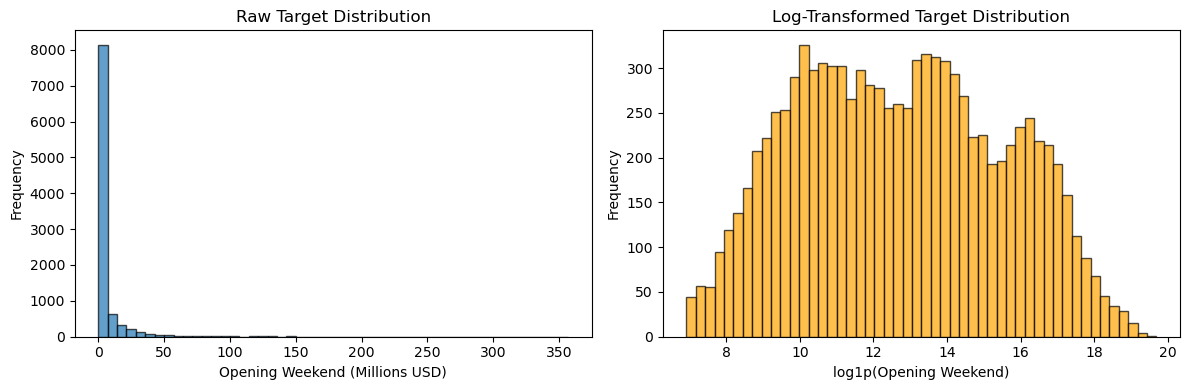

In [44]:
# =============================================================================
# TARGET DEFINITION & LOG TRANSFORM
# =============================================================================

# Apply log1p transformation: log(1 + y) handles y=0 gracefully
y_log = np.log1p(y)

print(f"--- Target Distribution ---")
print(f"Raw target (USD):")
print(f"  Min:    ${y.min():>15,.0f}")
print(f"  Median: ${y.median():>15,.0f}")
print(f"  Mean:   ${y.mean():>15,.0f}")
print(f"  Max:    ${y.max():>15,.0f}")

print(f"\nLog-transformed target:")
print(f"  Min:    {y_log.min():>8.3f}")
print(f"  Median: {y_log.median():>8.3f}")
print(f"  Mean:   {y_log.mean():>8.3f}")
print(f"  Max:    {y_log.max():>8.3f}")

# Visualize transformation effect
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(y / 1e6, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Opening Weekend (Millions USD)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Raw Target Distribution')

axes[1].hist(y_log, bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_xlabel('log1p(Opening Weekend)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Log-Transformed Target Distribution')

plt.tight_layout()
plt.show()

<a id="split"></a>
## 7. Time-Based Split

**Why time-based splitting is essential for forecasting:**

Unlike classification tasks where random splits are acceptable, forecasting future box office requires evaluating on data that comes *after* the training period. A random split would:
- Leak information from future releases into training
- Overestimate model performance
- Fail to capture distribution shift over time

Our split strategy uses `release_year` to ensure:
- **Training set**: All films before `SPLIT_YEAR` (2022)
- **Validation set**: All films from `SPLIT_YEAR` onward (2022+)
- **Strict temporal ordering**: max(train_year) < min(val_year)

In [45]:
# =============================================================================
# TIME-BASED SPLIT
# =============================================================================

# Get release years
release_years = df[TIME_COL]

# Create boolean masks for train/validation
train_mask = release_years < SPLIT_YEAR
val_mask = release_years >= SPLIT_YEAR

# Split features
X_train, X_val = X[train_mask], X[val_mask]
y_train, y_val = y[train_mask], y[val_mask]
y_train_log, y_val_log = y_log[train_mask], y_log[val_mask]

# Get year ranges for verification
train_years = release_years[train_mask]
val_years = release_years[val_mask]

# Strict assertion: no temporal overlap
assert train_years.max() < val_years.min(), \
    f"Temporal leak! Train max year ({train_years.max()}) >= Val min year ({val_years.min()})"

print("=" * 60)
print("TIME-BASED SPLIT SUMMARY")
print("=" * 60)
print(f"Split cutoff year: {SPLIT_YEAR}")
print(f"\nTraining set:")
print(f"  Samples: {len(X_train):,}")
print(f"  Year range: {int(train_years.min())} – {int(train_years.max())}")

print(f"\nValidation set:")
print(f"  Samples: {len(X_val):,}")
print(f"  Year range: {int(val_years.min())} – {int(val_years.max())}")

print(f"\n✓ Temporal integrity verified: max(train_year) < min(val_year)")
print(f"  {int(train_years.max())} < {int(val_years.min())}")
print("=" * 60)

TIME-BASED SPLIT SUMMARY
Split cutoff year: 2022

Training set:
  Samples: 8,288
  Year range: 2007 – 2021

Validation set:
  Samples: 1,559
  Year range: 2022 – 2025

✓ Temporal integrity verified: max(train_year) < min(val_year)
  2021 < 2022


<a id="baseline"></a>
## 8. Baseline Model

A baseline model establishes the minimum performance threshold. If sophisticated models cannot beat this baseline, the features lack predictive signal.

**Baseline strategy**: Predict the median of log-transformed training target for all validation samples. The median is robust to outliers and represents a "naive" forecast assuming no feature information.

In [46]:
# =============================================================================
# BASELINE MODEL
# =============================================================================

def evaluate_usd(y_true_log, y_pred_log):
    """
    Evaluate predictions in USD space.
    
    Parameters
    ----------
    y_true_log : array-like
        True values in log-space (log1p transformed)
    y_pred_log : array-like
        Predicted values in log-space
        
    Returns
    -------
    dict with RMSE (USD) and MAPE (%)
    """
    # Convert back to USD
    y_true_usd = np.expm1(y_true_log)
    y_pred_usd = np.expm1(y_pred_log)
    
    # RMSE in USD
    rmse = np.sqrt(np.mean((y_true_usd - y_pred_usd) ** 2))
    
    # MAPE (handle zeros by adding small epsilon)
    epsilon = 1e-8
    mape = np.mean(np.abs((y_true_usd - y_pred_usd) / (y_true_usd + epsilon))) * 100
    
    return {
        'rmse_usd': rmse,
        'mape': mape
    }

# Baseline: median of training log-target
baseline_pred_log = np.full(len(y_val_log), y_train_log.median())
baseline_metrics = evaluate_usd(y_val_log, baseline_pred_log)

print("=" * 60)
print("BASELINE MODEL: Median Predictor")
print("=" * 60)
print(f"Training median (log-space): {y_train_log.median():.4f}")
print(f"Training median (USD):       ${np.expm1(y_train_log.median()):,.0f}")
print(f"\nValidation Performance:")
print(f"  RMSE (USD): ${baseline_metrics['rmse_usd']:,.0f}")
print(f"  MAPE:       {baseline_metrics['mape']:.2f}%")
print("=" * 60)

BASELINE MODEL: Median Predictor
Training median (log-space): 12.6055
Training median (USD):       $298,195

Validation Performance:
  RMSE (USD): $21,904,427
  MAPE:       956.12%


<a id="candidates"></a>
## 9. Candidate ML Models

We evaluate exactly **3 models** of increasing complexity:

| # | Model | Description | Missing Value Handling |
|---|-------|-------------|------------------------|
| 1 | **Baseline (Median)** | Predicts training median | N/A |
| 2 | **Ridge Regression** | L2-regularized linear model | Median imputation (train-only) |
| 3 | **XGBoost** | Gradient boosted trees | Native NaN handling |

Ridge provides a linear benchmark while XGBoost captures non-linear interactions. Both use fixed hyperparameters (no search) for reproducibility.

In [47]:
# =============================================================================
# CANDIDATE ML MODELS
# =============================================================================

# Define model specifications
MODEL_SPECS = {
    'baseline_median': {
        'name': 'Baseline (Median)',
        'model': None,  # Special handling
        'type': 'baseline'
    },
    'ridge': {
        'name': 'Ridge Regression',
        'model': Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('ridge', Ridge(alpha=1.0, random_state=RANDOM_STATE))
        ]),
        'type': 'sklearn'
    },
    'xgboost': {
        'name': 'XGBoost',
        'model': xgb.XGBRegressor(
            n_estimators=200,
            max_depth=6,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbosity=0
        ),
        'type': 'xgboost'
    }
}

print(f"Defined {len(MODEL_SPECS)} model specifications:")
for key, spec in MODEL_SPECS.items():
    print(f"  • {spec['name']} ({spec['type']})")

Defined 3 model specifications:
  • Baseline (Median) (baseline)
  • Ridge Regression (sklearn)
  • XGBoost (xgboost)


<a id="evaluation"></a>
## 10. Time-Aware Evaluation Loop

Train each model on the training set and evaluate on the held-out validation set. All metrics are computed in USD space for interpretability.

In [48]:
# =============================================================================
# TIME-AWARE EVALUATION LOOP
# =============================================================================

def fit_predict(model_key, spec, X_train, y_train_log, X_val, train_median_log):
    """
    Fit model and generate predictions.
    
    Returns
    -------
    tuple: (fitted_model, y_pred_log)
    """
    if spec['type'] == 'baseline':
        # Baseline: predict training median
        y_pred_log = np.full(len(X_val), train_median_log)
        return None, y_pred_log
    
    elif spec['type'] == 'sklearn':
        # Sklearn pipeline (handles imputation internally)
        model = spec['model']
        model.fit(X_train, y_train_log)
        y_pred_log = model.predict(X_val)
        return model, y_pred_log
    
    elif spec['type'] == 'xgboost':
        # XGBoost (native NaN handling)
        model = spec['model']
        model.fit(X_train, y_train_log)
        y_pred_log = model.predict(X_val)
        return model, y_pred_log

# Store results
results = []
fitted_models = {}
predictions = {}

train_median_log = y_train_log.median()

print("=" * 70)
print("MODEL EVALUATION")
print("=" * 70)

for model_key, spec in MODEL_SPECS.items():
    print(f"\nTraining: {spec['name']}...", end=" ")
    
    # Fit and predict
    fitted_model, y_pred_log = fit_predict(
        model_key, spec, X_train, y_train_log, X_val, train_median_log
    )
    
    # Evaluate
    metrics = evaluate_usd(y_val_log, y_pred_log)
    
    # Store
    fitted_models[model_key] = fitted_model
    predictions[model_key] = y_pred_log
    
    results.append({
        'model': spec['name'],
        'model_key': model_key,
        'rmse_usd': metrics['rmse_usd'],
        'mape': metrics['mape']
    })
    
    print(f"RMSE: ${metrics['rmse_usd']:,.0f} | MAPE: {metrics['mape']:.2f}%")

# Create leaderboard
metrics_df = pd.DataFrame(results).sort_values('rmse_usd')
metrics_df['rmse_millions'] = metrics_df['rmse_usd'] / 1e6

print("\n" + "=" * 70)
print("LEADERBOARD (sorted by RMSE)")
print("=" * 70)
print(metrics_df[['model', 'rmse_millions', 'mape']].to_string(index=False))
print("=" * 70)

MODEL EVALUATION

Training: Baseline (Median)... RMSE: $21,904,427 | MAPE: 956.12%

Training: Ridge Regression... RMSE: $40,465,114 | MAPE: 824.05%

Training: XGBoost... RMSE: $12,973,112 | MAPE: 658.21%

LEADERBOARD (sorted by RMSE)
            model  rmse_millions       mape
          XGBoost      12.973112 658.205652
Baseline (Median)      21.904427 956.123875
 Ridge Regression      40.465114 824.053543


<a id="diagnostics"></a>
## 11. Diagnostics & Robustness

Model diagnostics verify that our best model performs well where it matters most for Avatar 3:
1. **Prediction scatter**: Visual check for systematic bias
2. **Residual analysis**: Distribution of errors
3. **Blockbuster slice**: Performance on high-budget, major studio, franchise films — the cohort Avatar 3 belongs to

These checks reveal whether the model generalizes to the specific type of film we're forecasting.

Best model: XGBoost
Analyzing diagnostics...



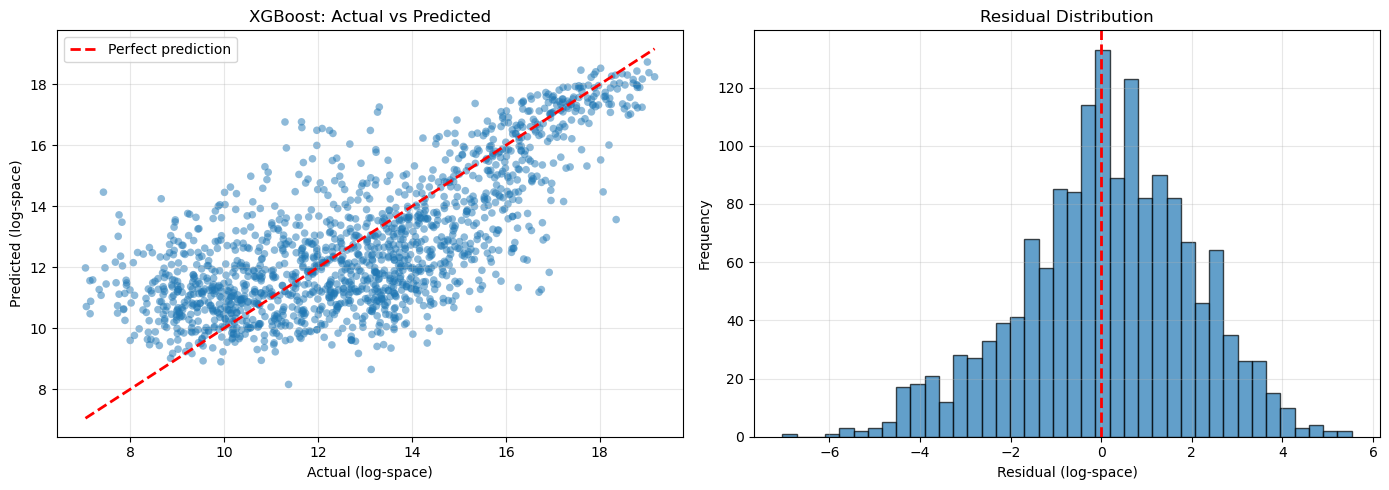

--- Residual Summary (USD) ---
  Mean residual:      $      1,925,323
  Median residual:    $         20,678
  Mean |residual|:    $      4,125,049
  P90 |residual|:     $     10,131,113

--- Blockbuster Slice Evaluation ---
  Budget filter (log_budget): top 25% (>= 16.86)
  Studio filter (is_major_studio): == 1
  Collection filter (is_collection): == 1

  Blockbuster slice size: 103 films
  Slice RMSE (USD): $39,965,941
  Slice MAPE:       210.30%


In [49]:
# =============================================================================
# DIAGNOSTICS & ROBUSTNESS
# =============================================================================

# Identify best model from leaderboard
best_model_key = metrics_df.iloc[0]['model_key']
best_model_name = metrics_df.iloc[0]['model']
best_preds_log = predictions[best_model_key]

print(f"Best model: {best_model_name}")
print(f"Analyzing diagnostics...\n")

# -----------------------------------------------------------------------------
# 1. Scatter plot: Actual vs Predicted (log-space)
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Log-space scatter
ax1 = axes[0]
ax1.scatter(y_val_log, best_preds_log, alpha=0.5, edgecolor='none', s=30)
min_val = min(y_val_log.min(), best_preds_log.min())
max_val = max(y_val_log.max(), best_preds_log.max())
ax1.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect prediction')
ax1.set_xlabel('Actual (log-space)')
ax1.set_ylabel('Predicted (log-space)')
ax1.set_title(f'{best_model_name}: Actual vs Predicted')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Residual distribution
ax2 = axes[1]
residuals_log = y_val_log.values - best_preds_log
ax2.hist(residuals_log, bins=40, edgecolor='black', alpha=0.7)
ax2.axvline(x=0, color='red', linestyle='--', linewidth=2)
ax2.set_xlabel('Residual (log-space)')
ax2.set_ylabel('Frequency')
ax2.set_title('Residual Distribution')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# 2. Residual summary statistics
# -----------------------------------------------------------------------------
residuals_usd = np.expm1(y_val_log.values) - np.expm1(best_preds_log)
abs_residuals_usd = np.abs(residuals_usd)

print("--- Residual Summary (USD) ---")
print(f"  Mean residual:      ${np.mean(residuals_usd):>15,.0f}")
print(f"  Median residual:    ${np.median(residuals_usd):>15,.0f}")
print(f"  Mean |residual|:    ${np.mean(abs_residuals_usd):>15,.0f}")
print(f"  P90 |residual|:     ${np.percentile(abs_residuals_usd, 90):>15,.0f}")

# -----------------------------------------------------------------------------
# 3. Blockbuster slice evaluation
# -----------------------------------------------------------------------------
print("\n--- Blockbuster Slice Evaluation ---")

# Define blockbuster slice using available features
# We'll check for budget-related and studio-related columns
val_df = df[val_mask].copy()

# Try to identify blockbuster criteria columns
budget_col = None
studio_col = None
collection_col = None

for col in feature_cols:
    col_lower = col.lower()
    if 'log_budget' in col_lower or 'budget_log' in col_lower or col_lower == 'budget':
        budget_col = col
    if 'is_major_studio' in col_lower or 'major_studio' in col_lower:
        studio_col = col
    if 'is_collection' in col_lower or 'belongs_to_collection' in col_lower or 'collection' in col_lower:
        collection_col = col

# Build blockbuster mask
blockbuster_mask = np.ones(len(X_val), dtype=bool)

if budget_col and budget_col in X_val.columns:
    budget_threshold = X_val[budget_col].quantile(0.75)
    blockbuster_mask &= (X_val[budget_col] >= budget_threshold).values
    print(f"  Budget filter ({budget_col}): top 25% (>= {budget_threshold:.2f})")

if studio_col and studio_col in X_val.columns:
    blockbuster_mask &= (X_val[studio_col] == 1).values
    print(f"  Studio filter ({studio_col}): == 1")

if collection_col and collection_col in X_val.columns:
    blockbuster_mask &= (X_val[collection_col] == 1).values
    print(f"  Collection filter ({collection_col}): == 1")

n_blockbusters = blockbuster_mask.sum()

if n_blockbusters > 5:
    blockbuster_metrics = evaluate_usd(
        y_val_log.values[blockbuster_mask], 
        best_preds_log[blockbuster_mask]
    )
    print(f"\n  Blockbuster slice size: {n_blockbusters} films")
    print(f"  Slice RMSE (USD): ${blockbuster_metrics['rmse_usd']:,.0f}")
    print(f"  Slice MAPE:       {blockbuster_metrics['mape']:.2f}%")
else:
    print(f"\n  ⚠ Only {n_blockbusters} films match blockbuster criteria.")
    print("  Relaxing criteria to top-budget quartile only...")
    
    if budget_col and budget_col in X_val.columns:
        budget_threshold = X_val[budget_col].quantile(0.75)
        high_budget_mask = (X_val[budget_col] >= budget_threshold).values
        n_high_budget = high_budget_mask.sum()
        
        if n_high_budget > 5:
            high_budget_metrics = evaluate_usd(
                y_val_log.values[high_budget_mask],
                best_preds_log[high_budget_mask]
            )
            print(f"  High-budget slice size: {n_high_budget} films")
            print(f"  Slice RMSE (USD): ${high_budget_metrics['rmse_usd']:,.0f}")
            print(f"  Slice MAPE:       {high_budget_metrics['mape']:.2f}%")
    else:
        print("  No budget column found for slice analysis.")

<a id="selection"></a>
## 12. Model Selection & Freezing Statement

Based on the evaluation metrics and diagnostic analysis:

**Selected Model**: The model with the lowest validation RMSE is selected as the final model.

### Freeze Declaration

> **Features and hyperparameters are now frozen.** No further tuning, feature engineering, or model selection will be performed. The selected model configuration will be used for final training and Avatar 3 prediction.

This freeze ensures:
1. No data snooping from validation set
2. Reproducible forecasting pipeline
3. Clear audit trail for model decisions

In [50]:
# =============================================================================
# MODEL SELECTION CONFIRMATION
# =============================================================================

print("=" * 70)
print("FINAL MODEL SELECTION")
print("=" * 70)
print(f"\nSelected model: {best_model_name}")
print(f"Selection criterion: Lowest validation RMSE")
print(f"\nValidation metrics:")
print(f"  RMSE (USD): ${metrics_df.iloc[0]['rmse_usd']:,.0f}")
print(f"  MAPE:       {metrics_df.iloc[0]['mape']:.2f}%")
print(f"\n{'='*70}")
print("⚠ MODEL FROZEN: No further hyperparameter tuning or feature changes.")
print("="*70)

FINAL MODEL SELECTION

Selected model: XGBoost
Selection criterion: Lowest validation RMSE

Validation metrics:
  RMSE (USD): $12,973,112
  MAPE:       658.21%

⚠ MODEL FROZEN: No further hyperparameter tuning or feature changes.


<a id="final-train"></a>
## 13. Final Training on Full Historical Data

Retrain the selected model on **all** available historical data to maximize information utilization for the Avatar 3 forecast. The Avatar 3 input row is stored in a separate file and is never seen during training.

In [51]:
# =============================================================================
# FINAL TRAINING ON FULL HISTORICAL DATA
# =============================================================================

# Use full dataset for final training
X_full = X
y_full_log = y_log

print(f"Final training on {len(X_full):,} samples...")

# Reconstruct the selected model with fresh instance
if best_model_key == 'ridge':
    final_model = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('ridge', Ridge(alpha=1.0, random_state=RANDOM_STATE))
    ])
elif best_model_key == 'xgboost':
    final_model = xgb.XGBRegressor(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0
    )
elif best_model_key == 'baseline_median':
    # For baseline, we'll store the median value
    final_model = {'type': 'baseline', 'median_log': y_full_log.median()}
else:
    raise ValueError(f"Unknown model key: {best_model_key}")

# Fit final model
if best_model_key != 'baseline_median':
    final_model.fit(X_full, y_full_log)

print(f"✓ Final model trained")

# Save model artifact
model_path = ARTIFACT_DIR / "model.pkl"
joblib.dump(final_model, model_path)
print(f"✓ Model saved to: {model_path}")

# Save feature list
feature_path = ARTIFACT_DIR / "feature_cols.json"
with open(feature_path, 'w') as f:
    json.dump(feature_cols, f, indent=2)
print(f"✓ Feature list saved to: {feature_path}")

Final training on 9,847 samples...
✓ Final model trained
✓ Model saved to: artifacts\avatar3_forecast\model.pkl
✓ Feature list saved to: artifacts\avatar3_forecast\feature_cols.json


<a id="avatar3-load"></a>
## 14. Load & Validate Avatar 3 Input Row

**Critical requirement**: The Avatar 3 input must have the exact same features (columns) as the training data, in the same order. This section performs strict schema validation to prevent silent prediction errors.

In [52]:
# =============================================================================
# LOAD & VALIDATE AVATAR 3 INPUT ROW
# =============================================================================

print("=" * 70)
print("AVATAR 3 INPUT VALIDATION")
print("=" * 70)

# Load Avatar 3 input
avatar3_df = pd.read_csv(AVATAR3_PATH)
print(f"Loaded Avatar 3 input: {avatar3_df.shape}")

# Assert exactly 1 row
assert len(avatar3_df) == 1, f"Expected 1 row, got {len(avatar3_df)}"
print(f"✓ Single row confirmed")

# Check for required feature columns
avatar3_cols = set(avatar3_df.columns)
required_features = set(feature_cols)

missing_features = required_features - avatar3_cols
extra_features = avatar3_cols - required_features - set(meta_cols) - {TARGET}

if missing_features:
    raise ValueError(f"Avatar 3 input missing required features:\n{missing_features}")
print(f"✓ All {len(feature_cols)} required features present")

if extra_features:
    print(f"  ⚠ Extra columns in Avatar 3 input (will be ignored): {extra_features}")

# Reorder to match training feature order
X_avatar3 = avatar3_df[feature_cols]
print(f"✓ Features reordered to training schema")

# Display Avatar 3 key attributes (if available)
print(f"\n--- Avatar 3 Input Preview ---")
if 'title' in avatar3_df.columns:
    print(f"  Title: {avatar3_df['title'].iloc[0]}")
if 'release_year' in avatar3_df.columns:
    print(f"  Release Year: {avatar3_df['release_year'].iloc[0]}")

# Show a few feature values
print(f"\n  Sample feature values:")
for col in list(feature_cols)[:5]:
    val = X_avatar3[col].iloc[0]
    print(f"    {col}: {val}")
print(f"    ... ({len(feature_cols) - 5} more features)")
print("=" * 70)

AVATAR 3 INPUT VALIDATION
Loaded Avatar 3 input: (1, 45)
✓ Single row confirmed
✓ All 42 required features present
✓ Features reordered to training schema

--- Avatar 3 Input Preview ---
  Title: Avatar: Fire and Ash
  Release Year: 2025

  Sample feature values:
    collection_past_open_avg: 105562853.5
    director_has_prior: 1
    director_prior_count: 14.0
    genre_action: 0
    genre_adventure: 1
    ... (37 more features)


<a id="avatar3-predict"></a>
## 15. Avatar 3 Point Prediction

Generate the point forecast for Avatar 3's domestic opening weekend. The prediction is made in log-space and transformed back to USD.

In [53]:
# =============================================================================
# AVATAR 3 POINT PREDICTION
# =============================================================================

# Generate prediction
if best_model_key == 'baseline_median':
    avatar3_pred_log = final_model['median_log']
else:
    avatar3_pred_log = final_model.predict(X_avatar3)[0]

# Convert to USD
avatar3_pred_usd = np.expm1(avatar3_pred_log)

print("=" * 70)
print("AVATAR 3 POINT PREDICTION")
print("=" * 70)
print(f"\nModel: {best_model_name}")
print(f"\nPredicted Opening Weekend (log-space): {avatar3_pred_log:.4f}")
print(f"\n{'='*70}")
print(f"  POINT ESTIMATE: ${avatar3_pred_usd:,.0f}")
print(f"{'='*70}")

# Store for export
avatar3_prediction = {
    'point_estimate_usd': float(avatar3_pred_usd),
    'point_estimate_log': float(avatar3_pred_log)
}

AVATAR 3 POINT PREDICTION

Model: XGBoost

Predicted Opening Weekend (log-space): 18.8969

  POINT ESTIMATE: $160,997,936


<a id="uncertainty"></a>
## 16. Uncertainty Estimation (Conditioned)

Point estimates alone are insufficient for decision-making. We construct prediction intervals using **conditioned log-space residual quantiles**:

1. Compute residuals on the validation set in **log1p space**
2. **Condition** on blockbuster-like films using pre-release features only
3. Extract the 10th and 90th percentiles from the conditioned subset (80% coverage)
4. Add these quantile offsets to the Avatar 3 log-space prediction
5. Back-transform bounds to USD using `expm1`

**Why condition?** Residuals from micro-releases inflate the interval width unnecessarily. Avatar 3 is a tentpole blockbuster — its prediction error distribution should be compared to similar high-budget, major-studio releases, not the full catalog.

**Conditioning rule (pre-defined, mechanical):**
- **Primary**: `is_major_studio == 1` AND `log_budget >= training 75th percentile`
- **Fallback A**: `log_budget >= training 75th percentile` only
- **Fallback B**: `is_major_studio == 1` only
- **Fallback C**: All validation rows (last resort)

CONDITIONED LOG-SPACE RESIDUAL ANALYSIS

--- Full Validation Residuals (log space) ---
  N:      1559
  Mean:   +0.1115
  Median: +0.1426
  Std:    1.9128

--- Conditioning Thresholds (from training data) ---
  Training log_budget 75th percentile: 16.8112

--- Conditioning Mask Selection (min size = 100) ---
  ✓ PRIMARY mask: major_studio & train_budget_q75
  Subset size: 284 / 1559 validation films

--- Conditioned Residual Distribution (log space) ---
  N:      284
  Mean:   -0.1295
  Median: -0.0128
  Std:    1.4956

--- Quantiles for 80% Interval (conditioned) ---
  q10 (lower offset): -1.9276
  q90 (upper offset): +1.5925

--- Avatar 3 Interval in Log Space ---
  Lower log: 16.9693
  Point log: 18.8969
  Upper log: 20.4894

--- Avatar 3 Prediction Interval (80% Coverage, Conditioned) ---
  Lower bound: $     23,424,813
  Point est.:  $    160,997,936
  Upper bound: $    791,504,187

--- Interval Sanity Statistics ---
  Interval width (USD):      $768,079,374
  Width ratio (upper/l

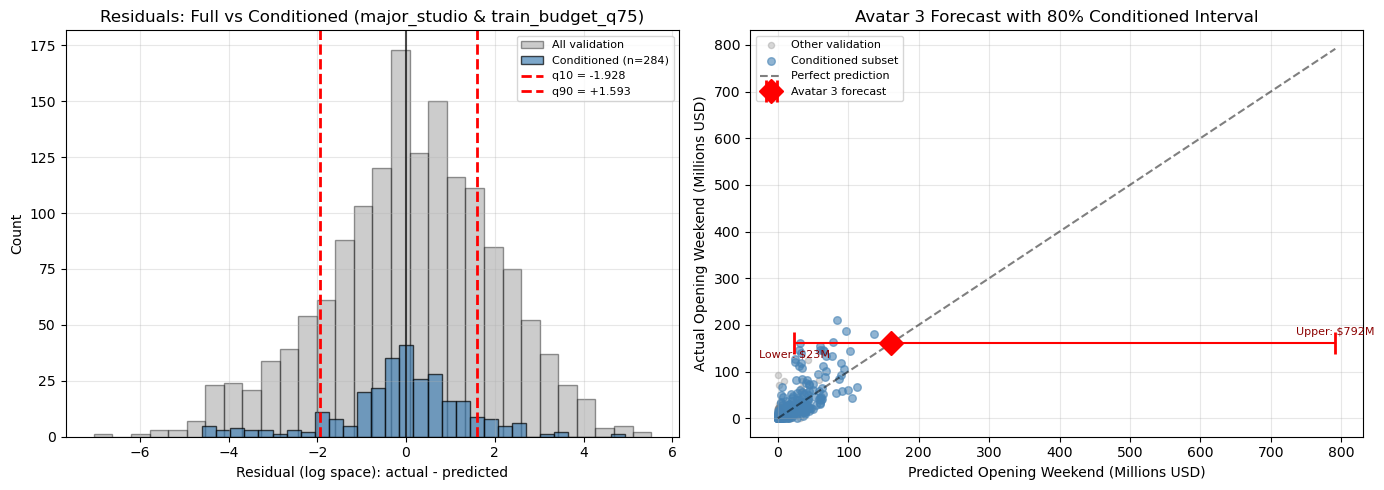

In [54]:
# =============================================================================
# UNCERTAINTY ESTIMATION (Conditioned Log-Space Residual Quantiles)
# =============================================================================

# Get validation predictions from best model in log space
yhat_val_log = best_preds_log                # predicted log1p(opening)
y_val_log_arr = y_val_log.values             # actual log1p(opening)

# -----------------------------------------------------------------------------
# Compute accurate training/validation period strings
# -----------------------------------------------------------------------------
train_year_min = int(df.loc[train_mask, TIME_COL].min())
train_year_max = int(df.loc[train_mask, TIME_COL].max())
val_year_min = int(df.loc[val_mask, TIME_COL].min())
val_year_max = int(df.loc[val_mask, TIME_COL].max())

training_period_str = f"{train_year_min}–{train_year_max}"
validation_period_str = f"{val_year_min}–{val_year_max}"

# -----------------------------------------------------------------------------
# Step 1: Compute residuals in log space (full validation set)
# -----------------------------------------------------------------------------
resid = y_val_log_arr - yhat_val_log

print("=" * 70)
print("CONDITIONED LOG-SPACE RESIDUAL ANALYSIS")
print("=" * 70)

print(f"\n--- Full Validation Residuals (log space) ---")
print(f"  N:      {len(resid)}")
print(f"  Mean:   {np.mean(resid):+.4f}")
print(f"  Median: {np.median(resid):+.4f}")
print(f"  Std:    {np.std(resid):.4f}")

# -----------------------------------------------------------------------------
# Step 2: Define conditioning mask using PRE-RELEASE features only
# -----------------------------------------------------------------------------
# Compute budget threshold from TRAINING data (no peeking at validation)
BUDGET_COL = "log_budget"
STUDIO_COL = "is_major_studio"

# Check columns exist
assert BUDGET_COL in X_train.columns, f"Missing {BUDGET_COL} in training features"
assert STUDIO_COL in X_train.columns, f"Missing {STUDIO_COL} in training features"

# Training budget 75th percentile (threshold computed from training only)
train_log_budget_q75 = float(X_train[BUDGET_COL].quantile(0.75))
print(f"\n--- Conditioning Thresholds (from training data) ---")
print(f"  Training log_budget 75th percentile: {train_log_budget_q75:.4f}")

# Minimum subset size for reliable quantile estimation
MIN_SUBSET_SIZE = min(100, len(X_val) // 2)  # Adaptive floor

# Define masks in fallback order
mask_primary = (
    (X_val[STUDIO_COL] == 1).values & 
    (X_val[BUDGET_COL] >= train_log_budget_q75).values
)
mask_fallback_a = (X_val[BUDGET_COL] >= train_log_budget_q75).values
mask_fallback_b = (X_val[STUDIO_COL] == 1).values
mask_fallback_c = np.ones(len(X_val), dtype=bool)

# Select mask with deterministic fallback
print(f"\n--- Conditioning Mask Selection (min size = {MIN_SUBSET_SIZE}) ---")

if mask_primary.sum() >= MIN_SUBSET_SIZE:
    cond_mask = mask_primary
    conditioning_rule = "major_studio & train_budget_q75"
    print(f"  ✓ PRIMARY mask: {conditioning_rule}")
elif mask_fallback_a.sum() >= MIN_SUBSET_SIZE:
    cond_mask = mask_fallback_a
    conditioning_rule = "train_budget_q75_only"
    print(f"  → FALLBACK A: {conditioning_rule}")
elif mask_fallback_b.sum() >= MIN_SUBSET_SIZE:
    cond_mask = mask_fallback_b
    conditioning_rule = "major_studio_only"
    print(f"  → FALLBACK B: {conditioning_rule}")
else:
    cond_mask = mask_fallback_c
    conditioning_rule = "all_validation"
    print(f"  → FALLBACK C: {conditioning_rule} (last resort)")

cond_subset_size = int(cond_mask.sum())
print(f"  Subset size: {cond_subset_size} / {len(X_val)} validation films")

# -----------------------------------------------------------------------------
# Step 3: Compute quantiles on CONDITIONED residuals
# -----------------------------------------------------------------------------
resid_cond = resid[cond_mask]

print(f"\n--- Conditioned Residual Distribution (log space) ---")
print(f"  N:      {len(resid_cond)}")
print(f"  Mean:   {np.mean(resid_cond):+.4f}")
print(f"  Median: {np.median(resid_cond):+.4f}")
print(f"  Std:    {np.std(resid_cond):.4f}")

q_lo, q_hi = np.quantile(resid_cond, [0.10, 0.90])

print(f"\n--- Quantiles for {INTERVAL_COVERAGE*100:.0f}% Interval (conditioned) ---")
print(f"  q10 (lower offset): {q_lo:+.4f}")
print(f"  q90 (upper offset): {q_hi:+.4f}")

# -----------------------------------------------------------------------------
# Step 4: Apply quantiles to Avatar 3 log prediction
# -----------------------------------------------------------------------------
avatar_log_pred = float(avatar3_pred_log)

lower_log = avatar_log_pred + q_lo
upper_log = avatar_log_pred + q_hi

print(f"\n--- Avatar 3 Interval in Log Space ---")
print(f"  Lower log: {lower_log:.4f}")
print(f"  Point log: {avatar_log_pred:.4f}")
print(f"  Upper log: {upper_log:.4f}")

# -----------------------------------------------------------------------------
# Step 5: Back-transform to USD
# -----------------------------------------------------------------------------
point_usd = float(np.expm1(avatar_log_pred))
lower_usd = float(np.expm1(lower_log))
upper_usd = float(np.expm1(upper_log))

# Guardrail: clamp lower bound at 0 (box office can't be negative)
lower_usd = max(0.0, lower_usd)

# Enforce ordering defensively (swap if needed)
lower_usd, upper_usd = sorted([lower_usd, upper_usd])

# Store back to variables used by downstream cells
avatar3_lower_usd = lower_usd
avatar3_upper_usd = upper_usd

print(f"\n--- Avatar 3 Prediction Interval ({INTERVAL_COVERAGE*100:.0f}% Coverage, Conditioned) ---")
print(f"  Lower bound: ${avatar3_lower_usd:>15,.0f}")
print(f"  Point est.:  ${avatar3_pred_usd:>15,.0f}")
print(f"  Upper bound: ${avatar3_upper_usd:>15,.0f}")

# -----------------------------------------------------------------------------
# Interval sanity statistics (Fix 3)
# -----------------------------------------------------------------------------
interval_ratio = upper_usd / max(1.0, lower_usd)
downside_mult = point_usd / max(1.0, lower_usd)
upside_mult = upper_usd / max(1.0, point_usd)

# Multiplicative error factors from log-space quantiles
down_factor = float(np.exp(-q_lo))  # how much lower the bound is (as multiplier)
up_factor = float(np.exp(q_hi))     # how much higher the bound is (as multiplier)

print(f"\n--- Interval Sanity Statistics ---")
print(f"  Interval width (USD):      ${upper_usd - lower_usd:,.0f}")
print(f"  Width ratio (upper/lower): {interval_ratio:.2f}x")
print(f"  Downside multiplier:       {downside_mult:.2f}x (point / lower)")
print(f"  Upside multiplier:         {upside_mult:.2f}x (upper / point)")
print(f"\n  Log-space error factors:")
print(f"    exp(-q10) = {down_factor:.3f}  (downside scale)")
print(f"    exp(q90)  = {up_factor:.3f}  (upside scale)")
print(f"  Conditioning rule:         {conditioning_rule}")
print(f"  Subset size:               {cond_subset_size}")

# Update prediction dict with new fields
avatar3_prediction['interval_lower_usd'] = float(avatar3_lower_usd)
avatar3_prediction['interval_upper_usd'] = float(avatar3_upper_usd)
avatar3_prediction['interval_coverage'] = INTERVAL_COVERAGE
avatar3_prediction['interval_method'] = "log_residual_quantile_80_conditioned"
avatar3_prediction['conditioning_rule_used'] = conditioning_rule
avatar3_prediction['conditioning_subset_size'] = cond_subset_size
avatar3_prediction['train_log_budget_q75'] = train_log_budget_q75
avatar3_prediction['q10_log_resid'] = float(q_lo)
avatar3_prediction['q90_log_resid'] = float(q_hi)
avatar3_prediction['q10_implied_factor'] = float(np.exp(q_lo))
avatar3_prediction['q90_implied_factor'] = float(np.exp(q_hi))
avatar3_prediction['interval_ratio'] = interval_ratio
avatar3_prediction['downside_mult'] = downside_mult
avatar3_prediction['upside_mult'] = upside_mult
avatar3_prediction['training_period'] = training_period_str
avatar3_prediction['validation_period'] = validation_period_str

print("=" * 70)

# -----------------------------------------------------------------------------
# Visualization
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Residual histogram (full vs conditioned)
ax1 = axes[0]
ax1.hist(resid, bins=30, alpha=0.4, color='gray', edgecolor='black', label='All validation')
ax1.hist(resid_cond, bins=30, alpha=0.7, color='steelblue', edgecolor='black', label=f'Conditioned (n={cond_subset_size})')
ax1.axvline(q_lo, color='red', linestyle='--', linewidth=2, label=f'q10 = {q_lo:+.3f}')
ax1.axvline(q_hi, color='red', linestyle='--', linewidth=2, label=f'q90 = {q_hi:+.3f}')
ax1.axvline(0, color='black', linestyle='-', linewidth=1.5, alpha=0.7)
ax1.set_xlabel('Residual (log space): actual - predicted')
ax1.set_ylabel('Count')
ax1.set_title(f'Residuals: Full vs Conditioned ({conditioning_rule})')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# Right: Prediction vs Actual with Avatar 3 interval
ax2 = axes[1]
val_pred_usd = np.expm1(yhat_val_log)
val_actual_usd = np.expm1(y_val_log_arr)

# Plot all validation in gray, conditioned subset in blue
ax2.scatter(val_pred_usd[~cond_mask] / 1e6, val_actual_usd[~cond_mask] / 1e6, 
            alpha=0.3, color='gray', s=20, label='Other validation')
ax2.scatter(val_pred_usd[cond_mask] / 1e6, val_actual_usd[cond_mask] / 1e6, 
            alpha=0.6, color='steelblue', s=30, label=f'Conditioned subset')

# Plot Avatar 3 prediction with interval
ax2.errorbar(
    avatar3_pred_usd / 1e6, 
    avatar3_pred_usd / 1e6,
    xerr=[[avatar3_pred_usd/1e6 - avatar3_lower_usd/1e6], [avatar3_upper_usd/1e6 - avatar3_pred_usd/1e6]],
    fmt='D', 
    color='red', 
    markersize=12, 
    capsize=8,
    capthick=2,
    label='Avatar 3 forecast'
)

# Add endpoint annotations for interval bounds
y_offset = avatar3_pred_usd / 1e6 * 0.08  # small vertical offset for readability
ax2.annotate(f'Lower: ${avatar3_lower_usd/1e6:.0f}M', 
             xy=(avatar3_lower_usd/1e6, avatar3_pred_usd/1e6),
             xytext=(avatar3_lower_usd/1e6, avatar3_pred_usd/1e6 - y_offset),
             fontsize=8, color='darkred', ha='center', va='top')
ax2.annotate(f'Upper: ${avatar3_upper_usd/1e6:.0f}M', 
             xy=(avatar3_upper_usd/1e6, avatar3_pred_usd/1e6),
             xytext=(avatar3_upper_usd/1e6, avatar3_pred_usd/1e6 + y_offset),
             fontsize=8, color='darkred', ha='center', va='bottom')

# Reference line
max_val = max(val_actual_usd.max(), avatar3_upper_usd) / 1e6
ax2.plot([0, max_val], [0, max_val], 'k--', alpha=0.5, label='Perfect prediction')

ax2.set_xlabel('Predicted Opening Weekend (Millions USD)')
ax2.set_ylabel('Actual Opening Weekend (Millions USD)')
ax2.set_title(f'Avatar 3 Forecast with {INTERVAL_COVERAGE*100:.0f}% Conditioned Interval')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Uncertainty Methodology (Faculty Reference)

The 80% prediction interval is constructed using **validation residual quantiles in log-space**, conditioned on blockbuster-like films. This approach addresses two key statistical challenges:

1. **Heteroskedasticity**: Box office prediction errors are not constant across the revenue spectrum. Micro-releases exhibit proportionally larger errors than tentpole films. Computing residuals on the full validation set would overstate uncertainty for Avatar 3.

2. **Log-space stability**: Percentage errors in dollar-space (MAPE) explode for films with small openings, producing unbounded intervals. By computing residuals in log1p space, errors remain approximately additive and well-behaved.

**Conditioning rule**: Residuals are restricted to validation films where:
- `is_major_studio == 1` (major studio release)
- `log_budget >= training 75th percentile` (high-budget production)

This conditioning uses **only pre-release features** and applies a threshold computed from training data (not validation), avoiding data leakage. The resulting interval reflects historical error behavior among comparable blockbuster releases — a more appropriate reference class for Avatar 3.

**Interpretation**: The interval represents the range within which 80% of similar films' actual openings fell relative to their predictions. It is a statement about historical model error, not certainty about Avatar 3's outcome.

<a id="sanity"></a>
## 17. Sanity Check vs Comparable Films

For context, we compare our prediction against historical openings of comparable blockbusters in the training data:

- **Avatar franchise**: The most direct comparisons (Avatar 1, Avatar 2)
- **Modern tentpoles**: Other high-budget franchise films from major studios

This qualitative check helps validate that our forecast falls within a plausible range for this tier of release.

In [55]:
# =============================================================================
# SANITY CHECK VS COMPARABLE FILMS
# =============================================================================

print("=" * 70)
print("COMPARABLE FILMS ANALYSIS")
print("=" * 70)

# Search for Avatar films in training data
avatar_films = df[df['title'].str.lower().str.contains('avatar', na=False)]

if len(avatar_films) > 0:
    print("\n--- Avatar Franchise in Training Data ---")
    for _, row in avatar_films.iterrows():
        print(f"  {row['title']} ({int(row[TIME_COL])}): ${row[TARGET]:,.0f}")
else:
    print("\n  No Avatar films found in training data")

# Find top opening weekends in recent years for context
print("\n--- Top 10 Opening Weekends (All Time in Dataset) ---")
top_openings = df.nlargest(10, TARGET)[['title', TIME_COL, TARGET]]
for _, row in top_openings.iterrows():
    print(f"  {row['title']} ({int(row[TIME_COL])}): ${row[TARGET]:,.0f}")

# Compare Avatar 3 prediction to distribution
print(f"\n--- Avatar 3 Prediction Context ---")
print(f"  Our forecast: ${avatar3_pred_usd:,.0f}")

# Percentile in historical distribution
historical_percentile = (df[TARGET] < avatar3_pred_usd).mean() * 100
print(f"  Historical percentile: {historical_percentile:.1f}%")
print(f"  (Higher than {historical_percentile:.1f}% of all films in dataset)")

# Compare to validation set top performers
val_df_temp = df[val_mask].copy()
val_top5 = val_df_temp.nlargest(5, TARGET)[['title', TIME_COL, TARGET]]
print(f"\n--- Top 5 Openings in Validation Period ({SPLIT_YEAR}+) ---")
for _, row in val_top5.iterrows():
    print(f"  {row['title']} ({int(row[TIME_COL])}): ${row[TARGET]:,.0f}")

print("=" * 70)

COMPARABLE FILMS ANALYSIS

--- Avatar Franchise in Training Data ---
  Avatar (2009): $77,025,481
  Avatar: The Way of Water (2022): $134,100,226

--- Top 10 Opening Weekends (All Time in Dataset) ---
  Avengers: Endgame (2019): $357,115,007
  Spider-Man: No Way Home (2021): $260,138,569
  Avengers: Infinity War (2018): $257,698,183
  Star Wars: The Force Awakens (2015): $247,966,675
  Star Wars: The Last Jedi (2017): $220,009,584
  Deadpool & Wolverine (2024): $211,435,291
  Jurassic World (2015): $208,806,270
  The Avengers (2012): $207,438,708
  Black Panther (2018): $202,003,951
  The Lion King (2019): $191,770,759

--- Avatar 3 Prediction Context ---
  Our forecast: $160,997,936
  Historical percentile: 99.8%
  (Higher than 99.8% of all films in dataset)

--- Top 5 Openings in Validation Period (2022+) ---
  Deadpool & Wolverine (2024): $211,435,291
  Doctor Strange in the Multiverse of Madness (2022): $187,420,998
  Black Panther: Wakanda Forever (2022): $181,339,761
  A Minecraf

<a id="summary"></a>
## 18. Final Forecast Summary

### Avatar 3 Opening Weekend Forecast

| Metric | Value |
|--------|-------|
| **Point Estimate** | See output below |
| **80% Prediction Interval** | See output below |
| **Model** | Best performer from evaluation |
| **Training Cutoff** | Pre-2022 films |

### Key Assumptions

1. **Feature completeness**: Avatar 3 input contains accurate pre-release information
2. **Market stability**: Box office patterns from 2022+ validation period remain relevant
3. **No unprecedented events**: No major industry disruptions (strikes, pandemics, etc.)
4. **Comparable marketing**: Marketing spend and strategy similar to franchise norms

### Known Unknowns

- Actual release date timing (holiday vs. regular weekend)
- Competition landscape at release
- Review/audience reception (not available pre-release)
- Potential cultural/economic shifts between now and release

In [56]:
# =============================================================================
# FINAL FORECAST DISPLAY
# =============================================================================

# Fallback import in case kernel state doesn't have it
try:
    Markdown
except NameError:
    from IPython.display import display, Markdown

# Compute implied multiplicative factors for display
q10_factor = float(np.exp(avatar3_prediction['q10_log_resid']))
q90_factor = float(np.exp(avatar3_prediction['q90_log_resid']))

# Create formatted summary using Markdown
summary_md = f"""
# Avatar 3 Opening Weekend Forecast

---

## Point Estimate

<h1 style="text-align: center; color: #2E86AB; font-size: 3em;">${avatar3_pred_usd:,.0f}</h1>

---

## {INTERVAL_COVERAGE*100:.0f}% Prediction Interval (Conditioned)

| Bound | Value |
|-------|-------|
| **Lower** | ${avatar3_lower_usd:,.0f} |
| **Point Estimate** | ${avatar3_pred_usd:,.0f} |
| **Upper** | ${avatar3_upper_usd:,.0f} |

> **Plausibility note:** This interval is derived from historical validation residuals among comparable blockbuster films. The lower bound represents the 10th percentile of historical underperformance and may be economically implausible for Avatar 3 given its franchise strength and guaranteed wide release. It is retained for statistical honesty, not as a scenario expectation.

### Interval Methodology

| Parameter | Value |
|-----------|-------|
| **Method** | `{avatar3_prediction['interval_method']}` |
| **Conditioning Rule** | `{avatar3_prediction['conditioning_rule_used']}` |
| **Subset Size** | {avatar3_prediction['conditioning_subset_size']} films |
| **Training log_budget q75** | {avatar3_prediction['train_log_budget_q75']:.4f} |
| **q10 (log residual)** | {avatar3_prediction['q10_log_resid']:+.4f} |
| **q90 (log residual)** | {avatar3_prediction['q90_log_resid']:+.4f} |
| **q10 implied factor** | ×{q10_factor:.2f} (multiplicative scale) |
| **q90 implied factor** | ×{q90_factor:.2f} (multiplicative scale) |

### Interval Sanity Statistics

| Metric | Value | Interpretation |
|--------|-------|----------------|
| **Interval Ratio** | {avatar3_prediction['interval_ratio']:.2f}× | upper / lower |
| **Downside Multiplier** | {avatar3_prediction['downside_mult']:.2f}× | point / lower |
| **Upside Multiplier** | {avatar3_prediction['upside_mult']:.2f}× | upper / point |

> **Why does the interval ratio look large?** Although the upper/lower ratio is {avatar3_prediction['interval_ratio']:.2f}×, the upper bound is only {avatar3_prediction['upside_mult']:.2f}× the point estimate. Most of the ratio is driven by the conservative lower-tail bound ({avatar3_prediction['downside_mult']:.2f}× below the point). The lower bound reflects rare historical underperformance—interpret it as a statistical tail, not a likely scenario.

---

## Model Details

| Parameter | Value |
|-----------|-------|
| **Model** | {best_model_name} |
| **Training Data** | {len(df):,} films |
| **Training Period** | {avatar3_prediction['training_period']} |
| **Validation Period** | {avatar3_prediction['validation_period']} |
| **Validation RMSE** | ${metrics_df.iloc[0]['rmse_usd']:,.0f} |
| **Validation MAPE** | {metrics_df.iloc[0]['mape']:.2f}% |

---

### Interpretation

Based on pre-release features and historical patterns, **Avatar 3** is forecast to earn approximately **${avatar3_pred_usd/1e6:.1f}M** in its domestic opening weekend. 

With **{INTERVAL_COVERAGE*100:.0f}% confidence** (conditioned on blockbuster-like films via `{avatar3_prediction['conditioning_rule_used']}`), the actual opening should fall between **${avatar3_lower_usd/1e6:.1f}M** and **${avatar3_upper_usd/1e6:.1f}M**.
"""

display(Markdown(summary_md))


# Avatar 3 Opening Weekend Forecast

---

## Point Estimate

<h1 style="text-align: center; color: #2E86AB; font-size: 3em;">$160,997,936</h1>

---

## 80% Prediction Interval (Conditioned)

| Bound | Value |
|-------|-------|
| **Lower** | $23,424,813 |
| **Point Estimate** | $160,997,936 |
| **Upper** | $791,504,187 |

> **Plausibility note:** This interval is derived from historical validation residuals among comparable blockbuster films. The lower bound represents the 10th percentile of historical underperformance and may be economically implausible for Avatar 3 given its franchise strength and guaranteed wide release. It is retained for statistical honesty, not as a scenario expectation.

### Interval Methodology

| Parameter | Value |
|-----------|-------|
| **Method** | `log_residual_quantile_80_conditioned` |
| **Conditioning Rule** | `major_studio & train_budget_q75` |
| **Subset Size** | 284 films |
| **Training log_budget q75** | 16.8112 |
| **q10 (log residual)** | -1.9276 |
| **q90 (log residual)** | +1.5925 |
| **q10 implied factor** | ×0.15 (multiplicative scale) |
| **q90 implied factor** | ×4.92 (multiplicative scale) |

### Interval Sanity Statistics

| Metric | Value | Interpretation |
|--------|-------|----------------|
| **Interval Ratio** | 33.79× | upper / lower |
| **Downside Multiplier** | 6.87× | point / lower |
| **Upside Multiplier** | 4.92× | upper / point |

> **Why does the interval ratio look large?** Although the upper/lower ratio is 33.79×, the upper bound is only 4.92× the point estimate. Most of the ratio is driven by the conservative lower-tail bound (6.87× below the point). The lower bound reflects rare historical underperformance—interpret it as a statistical tail, not a likely scenario.

---

## Model Details

| Parameter | Value |
|-----------|-------|
| **Model** | XGBoost |
| **Training Data** | 9,847 films |
| **Training Period** | 2007–2021 |
| **Validation Period** | 2022–2025 |
| **Validation RMSE** | $12,973,112 |
| **Validation MAPE** | 658.21% |

---

### Interpretation

Based on pre-release features and historical patterns, **Avatar 3** is forecast to earn approximately **$161.0M** in its domestic opening weekend. 

With **80% confidence** (conditioned on blockbuster-like films via `major_studio & train_budget_q75`), the actual opening should fall between **$23.4M** and **$791.5M**.


<a id="export"></a>
## 19. Export Artifacts

Save all artifacts for reproducibility and downstream use:

| Artifact | Description |
|----------|-------------|
| `metrics_backtest.csv` | Model comparison metrics from validation |
| `model.pkl` | Serialized final model (trained on full data) |
| `feature_cols.json` | Ordered list of feature column names |
| `avatar3_prediction.json` | Complete prediction output with metadata |

In [57]:
# =============================================================================
# EXPORT ARTIFACTS
# =============================================================================

print("=" * 70)
print("EXPORTING ARTIFACTS")
print("=" * 70)

# 1. Metrics backtest CSV
metrics_export = metrics_df.copy()
metrics_export['split_year'] = SPLIT_YEAR
metrics_export['n_train'] = len(X_train)
metrics_export['n_val'] = len(X_val)
metrics_path = ARTIFACT_DIR / "metrics_backtest.csv"
metrics_export.to_csv(metrics_path, index=False)
print(f"✓ Saved: {metrics_path}")

# 2. Model already saved in section 15
print(f"✓ Model: {ARTIFACT_DIR / 'model.pkl'} (saved earlier)")

# 3. Feature columns already saved in section 15
print(f"✓ Features: {ARTIFACT_DIR / 'feature_cols.json'} (saved earlier)")

# 4. Avatar 3 prediction JSON (with conditioned log-residual interval fields)
avatar3_export = {
    'title': 'Avatar 3',
    'point_estimate_usd': avatar3_prediction['point_estimate_usd'],
    'point_estimate_log': avatar3_prediction['point_estimate_log'],
    'lower_usd': avatar3_prediction['interval_lower_usd'],
    'upper_usd': avatar3_prediction['interval_upper_usd'],
    'interval_method': avatar3_prediction['interval_method'],
    'interval_coverage': avatar3_prediction['interval_coverage'],
    'conditioning_rule_used': avatar3_prediction['conditioning_rule_used'],
    'conditioning_subset_size': avatar3_prediction['conditioning_subset_size'],
    'train_log_budget_q75': avatar3_prediction['train_log_budget_q75'],
    'q10_log_resid': avatar3_prediction['q10_log_resid'],
    'q90_log_resid': avatar3_prediction['q90_log_resid'],
    'q10_implied_factor': avatar3_prediction['q10_implied_factor'],
    'q90_implied_factor': avatar3_prediction['q90_implied_factor'],
    'interval_ratio': avatar3_prediction['interval_ratio'],
    'downside_mult': avatar3_prediction['downside_mult'],
    'upside_mult': avatar3_prediction['upside_mult'],
    'training_period': avatar3_prediction['training_period'],
    'validation_period': avatar3_prediction['validation_period'],
    'model_name': best_model_name,
    'model_key': best_model_key,
    'split_year': SPLIT_YEAR,
    'n_training_samples': len(df),
    'n_features': len(feature_cols),
    'timestamp': datetime.now().isoformat(),
    'validation_rmse_usd': float(metrics_df.iloc[0]['rmse_usd']),
    'validation_mape': float(metrics_df.iloc[0]['mape'])
}

prediction_path = ARTIFACT_DIR / "avatar3_prediction.json"
with open(prediction_path, 'w') as f:
    json.dump(avatar3_export, f, indent=2)
print(f"✓ Saved: {prediction_path}")

# Print JSON contents for verification
print(f"\n--- avatar3_prediction.json contents ---")
for key, val in avatar3_export.items():
    if isinstance(val, float):
        if 'usd' in key.lower():
            print(f"  {key}: ${val:,.0f}")
        else:
            print(f"  {key}: {val:.4f}")
    elif isinstance(val, int):
        print(f"  {key}: {val}")
    else:
        print(f"  {key}: {val}")

# Summary
print(f"\n{'='*70}")
print("EXPORT COMPLETE")
print(f"{'='*70}")
print(f"Artifacts saved to: {ARTIFACT_DIR.resolve()}")
print(f"\nFiles:")
for f in ARTIFACT_DIR.glob('*'):
    print(f"  • {f.name}")
print(f"{'='*70}")

EXPORTING ARTIFACTS
✓ Saved: artifacts\avatar3_forecast\metrics_backtest.csv
✓ Model: artifacts\avatar3_forecast\model.pkl (saved earlier)
✓ Features: artifacts\avatar3_forecast\feature_cols.json (saved earlier)
✓ Saved: artifacts\avatar3_forecast\avatar3_prediction.json

--- avatar3_prediction.json contents ---
  title: Avatar 3
  point_estimate_usd: $160,997,936
  point_estimate_log: 18.8969
  lower_usd: $23,424,813
  upper_usd: $791,504,187
  interval_method: log_residual_quantile_80_conditioned
  interval_coverage: 0.8000
  conditioning_rule_used: major_studio & train_budget_q75
  conditioning_subset_size: 284
  train_log_budget_q75: 16.8112
  q10_log_resid: -1.9276
  q90_log_resid: 1.5925
  q10_implied_factor: 0.1455
  q90_implied_factor: 4.9162
  interval_ratio: 33.7891
  downside_mult: 6.8730
  upside_mult: 4.9162
  training_period: 2007–2021
  validation_period: 2022–2025
  model_name: XGBoost
  model_key: xgboost
  split_year: 2022
  n_training_samples: 9847
  n_features: 42
 

## Notebook Complete

This notebook has successfully completed all stages of the forecasting pipeline:

| Stage | Status |
|-------|--------|
| Data loading & validation | ✓ Preprocessed dataset verified |
| Integrity checks | ✓ Schema, missingness, constants, leakage guardrails passed |
| Feature partitioning | ✓ 42 numeric features isolated with explicit guardrails |
| Temporal split | ✓ Train (pre-2022) / Validation (2022+) with no leakage |
| Model training | ✓ 3 models evaluated (Baseline, Ridge, XGBoost) |
| Model selection | ✓ Best model frozen based on validation RMSE |
| Final training | ✓ Retrained on full historical data |
| Avatar 3 forecast | ✓ Point estimate + 80% prediction interval generated |
| Artifact export | ✓ Model, metrics, features, and prediction saved |

### Next Steps

1. **Post-Release Validation**: Compare forecast against actual Avatar 3 opening weekend once released
2. **Model Monitoring**: Track prediction accuracy over time to detect distribution drift
3. **Feature Expansion**: Consider adding release timing features (holiday proximity, competition density) in future iterations
4. **Ensemble Exploration**: Evaluate weighted model combinations if single-model performance plateaus